In [1]:
#Include the libraries needed
import pandas as pd
import numpy as np
import time
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from functions import feature_engineering, label, create_sequences, import_csv


In [2]:
#Create vectors containing name of the csv files we want to use
benign_csv = [
    "Benign-14.csv",
    "Benign-15.csv",
    "Benign-16.csv",
    "Benign-17.csv",
    "Benign-18.csv",
    #"Benign-19.csv",
    #"Benign-20.csv",
    #"Benign-21.csv",
    #"Benign-22.csv",
    #"Benign-23.csv",
    #"Benign-24.csv",
    #"Benign-25.csv",
    #"Benign-26.csv",
    #"Benign-27.csv",
    #"Benign-28.csv",
    #"Benign-29.csv",
    #"Benign-30.csv",
    #"Benign-31.csv",
    #"Benign-32.csv"
]


csv_folder = Path.cwd()/"CSV files"


In [3]:
#Import CSV files and transform them to df
benign_df = import_csv(benign_csv, csv_folder)
print("benign_df shape:", benign_df.shape)

Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Benign-14.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Benign-15.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Benign-16.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Benign-17.csv
Reading: C:\Users\Even_\OneDrive\Master\Dataset\Jupyter\CSV files\Benign-18.csv
benign_df shape: (1075456, 14)


In [4]:
train = feature_engineering(benign_df)
print("train shape:", train.shape)

train shape: (1075456, 18)


In [5]:
#Scale data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)

In [6]:
#Create sequences for LSTM 
window_size = 30
X_seq = create_sequences(train_scaled, window_size)
print("X_seq shape:", X_seq.shape)

X_seq shape: (1075427, 30, 18)


In [7]:
X_train_seq, X_val_seq = train_test_split(
    X_seq,
    test_size=0.2,
    shuffle=False
)

In [8]:
feature_columns = train.columns.tolist()

In [9]:
#deleting variables no longer used to free up memory
del train
del train_scaled
del X_seq
del benign_df

In [10]:
#Build LSTM autoecoder

timesteps = X_train_seq.shape[1]
n_features = X_train_seq.shape[2]

inputs = Input(shape=(timesteps, n_features))

# Encoder
x = LSTM(64, activation="tanh", return_sequences=True)(inputs)
x = Dropout(0.2)(x)
x = LSTM(32, activation="tanh", return_sequences=False)(x)

# Bottleneck
encoded = Dense(16, activation="relu")(x)

# Decoder
x = RepeatVector(timesteps)(encoded)
x = LSTM(32, activation="tanh", return_sequences=True)(x)
x = Dropout(0.2)(x)
x = LSTM(64, activation="tanh", return_sequences=True)(x)

# Output: samme shape som input
outputs = TimeDistributed(Dense(n_features))(x)

model = Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 30, 18)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 30, 64)              │          21,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 30, 16)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 30, 32)              │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 30, 64)              │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed (TimeDistributed)   │ (None, 30, 18)              │           1,170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 66,466 (259.63 KB)

 Trainable params: 66,466 (259.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Define early stopping criterias
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

#Get start time
start_time = time.time()

#Train model
history = model.fit(
    X_train_seq,
    X_train_seq,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_seq, X_val_seq),
    callbacks=[early_stop],
    shuffle=False
)

#Get end time and calculate training time
end_time = time.time()
training_time = end_time - start_time

print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Epoch 1/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 741s 54ms/step - loss: 0.0357 - val_loss: 0.0275
Epoch 2/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 706s 53ms/step - loss: 0.0125 - val_loss: 0.0124
Epoch 3/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 714s 53ms/step - loss: 0.0082 - val_loss: 0.0122
Epoch 4/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 718s 53ms/step - loss: 0.0072 - val_loss: 0.0118
Epoch 5/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 695s 52ms/step - loss: 0.0067 - val_loss: 0.0109
Epoch 6/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 693s 52ms/step - loss: 0.0059 - val_loss: 0.0106
Epoch 7/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 695s 52ms/step - loss: 0.0056 - val_loss: 0.0097
Epoch 8/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 697s 52ms/step - loss: 0.0054 - val_loss: 0.0089
Epoch 9/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 698s 52ms/step - loss: 0.0051 - val_loss: 0.0092
Epoch 10/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 700s 52ms/step - loss: 0.0050 - val_loss: 0.0087
Epoch 11/50
13443/13443 ━━━━━━━━━━━━━━━━━━━━ 697s 52ms/step - loss: 0

In [12]:
# Calculate reconstruction error based on normal trainingdata

X_train_pred = model.predict(X_train_seq)

train_loss = np.mean(
    np.mean((X_train_seq - X_train_pred) ** 2, axis=2),
    axis=1
)

print("Train reconstruction error:")
print(pd.Series(train_loss).describe())

26886/26886 ━━━━━━━━━━━━━━━━━━━━ 377s 14ms/step
Train reconstruction error:
count    860341.000000
mean          0.010634
std           0.014454
min           0.001004
25%           0.004545
50%           0.007122
75%           0.011734
max           0.132487
dtype: float64


In [13]:
# Sett anomaly threshold
threshold = np.percentile(train_loss, 99)

print("Threshold:", threshold)

Threshold: 0.10404626509857504


In [14]:
import joblib
from pathlib import Path

#save model
model_dir = Path("models/saved_lstm_autoencoder")
model_dir.mkdir(exist_ok=True)

# 1. Lagre Keras-modellen
model.save(model_dir / "lstm_autoencoder.keras")

# 2. Lagre scaler
joblib.dump(scaler, model_dir / "scaler.pkl")

# 3. Lagre threshold
joblib.dump(threshold, model_dir / "threshold.pkl")

# 4. Lagre feature columns
joblib.dump(feature_columns, model_dir / "feature_columns.pkl")

# 5. Lagre window size
joblib.dump(window_size, model_dir / "window_size.pkl")

print("Modell og tilhørende objekter er lagret.")

Modell og tilhørende objekter er lagret.


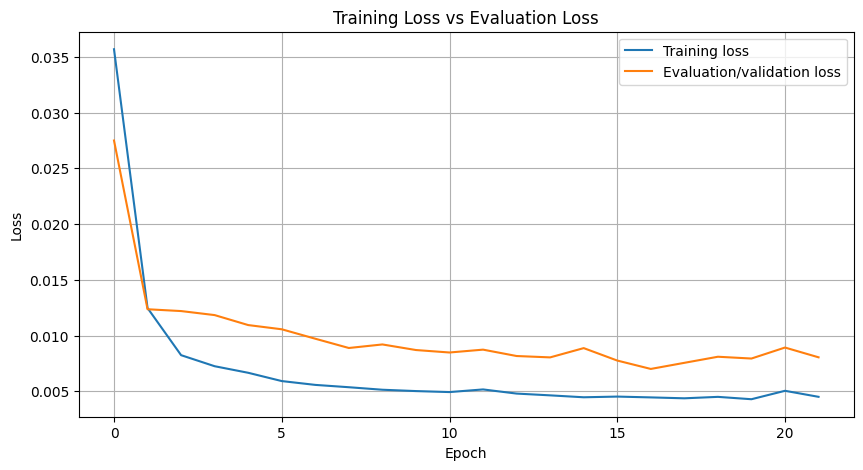

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Evaluation/validation loss")

plt.title("Training Loss vs Evaluation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()